In [18]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
from scipy.io import loadmat

SUBJECTS = helper_functions.get_subjects()

# Make envelope onset predictor

In [19]:
fdim = eelbrain.Scalar('frequency', [0])

for SUBJECT in SUBJECTS:

    dst_dir = file_paths.ENVELOPES_DIR / SUBJECT
    dst_dir.mkdir(exist_ok=True, parents=True)
    
    attended_onset_dst = dst_dir / f'{SUBJECT}_attended_envelope_onset.pickle'
    unattended_onset_dst = dst_dir / f'{SUBJECT}_unattended_envelope_onset.pickle'

    if attended_onset_dst.exists() and unattended_onset_dst.exists():
        print(f"Onset predictors for subject {SUBJECT} already exist. Skipping...")
        continue
    
    att_envelope_onset_trials = []
    unatt_envelope_onset_trials = []
    
    print("-" * 50)
    print(f"Processing subject {SUBJECT}...")
    
    attended_envelope_path = dst_dir / f"{SUBJECT}_attended_envelope.pickle"
    unattended_envelope_path = dst_dir / f"{SUBJECT}_unattended_envelope.pickle"

    if not attended_envelope_path.exists() or not unattended_envelope_path.exists():
        print(f"Envelope files for subject {SUBJECT} not found. Skipping...")
        continue

    # Load envelopes (these should already be NDVars)
    attended_envelope = eelbrain.load.unpickle(
        file_paths.ENVELOPES_DIR / SUBJECT / f"{SUBJECT}_attended_envelope.pickle"
    )
    unattended_envelope = eelbrain.load.unpickle(
        file_paths.ENVELOPES_DIR / SUBJECT / f"{SUBJECT}_unattended_envelope.pickle"
    )

    for att_ndvar, unatt_ndvar in zip([attended_envelope], [unattended_envelope]):

        # -------------------------------------------------
        # 1. Resample to 1000 Hz (required by edge detector)
        # -------------------------------------------------
        att_ndvar_1000 = eelbrain.resample(att_ndvar, 1000)
        unatt_ndvar_1000 = eelbrain.resample(unatt_ndvar, 1000)

        # -------------------------------------------------
        # 2. Add frequency dimension (make it 2D)
        # -------------------------------------------------
        att_2d = att_ndvar_1000.x[None, :]
        unatt_2d = unatt_ndvar_1000.x[None, :]

        att_ndvar_2d = eelbrain.NDVar(
            att_2d,
            dims=(fdim, att_ndvar_1000.time),
            name='attended'
        )

        unatt_ndvar_2d = eelbrain.NDVar(
            unatt_2d,
            dims=(fdim, unatt_ndvar_1000.time),
            name='unattended'
        )

        # -------------------------------------------------
        # 3. Run edge detector
        # -------------------------------------------------
        att_onset = eelbrain.edge_detector(att_ndvar_2d, c=30, name='attended_onset')
        unatt_onset = eelbrain.edge_detector(unatt_ndvar_2d, c=30, name='unattended_onset')

        # -------------------------------------------------
        # 4. Back to original sampling rate (64 Hz)
        # -------------------------------------------------
        att_onset = eelbrain.resample(att_onset, 64)
        unatt_onset = eelbrain.resample(unatt_onset, 64)

        # (optional) remove fake frequency dim again
        att_onset = att_onset.mean('frequency')
        unatt_onset = unatt_onset.mean('frequency')

        att_envelope_onset_trials.append(att_onset)
        unatt_envelope_onset_trials.append(unatt_onset)

    # -------------------------------------------------
    # 5. Concatenate + save
    # -------------------------------------------------
    att_concat = eelbrain.concatenate(att_envelope_onset_trials)
    unatt_concat = eelbrain.concatenate(unatt_envelope_onset_trials)

    eelbrain.save.pickle(att_concat, attended_onset_dst)
    eelbrain.save.pickle(unatt_concat, unattended_onset_dst)

--------------------------------------------------
Processing subject S1...
--------------------------------------------------
Processing subject S2...
--------------------------------------------------
Processing subject S3...
--------------------------------------------------
Processing subject S4...
--------------------------------------------------
Processing subject S5...
--------------------------------------------------
Processing subject S6...
--------------------------------------------------
Processing subject S7...
--------------------------------------------------
Processing subject S8...
--------------------------------------------------
Processing subject S9...
--------------------------------------------------
Processing subject S10...
--------------------------------------------------
Processing subject S11...
--------------------------------------------------
Processing subject S12...
--------------------------------------------------
Processing subject S13...
--------

In [29]:
attended_envelope, att_onset

(<NDVar 'attended': 192000 time>, <NDVar 'attended_onset': 192000 time>)

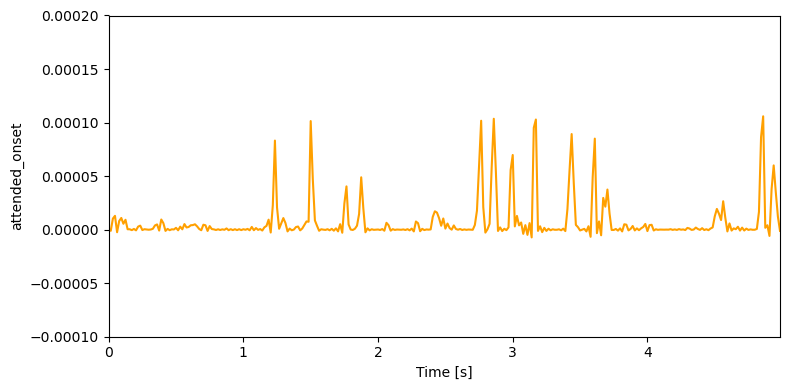

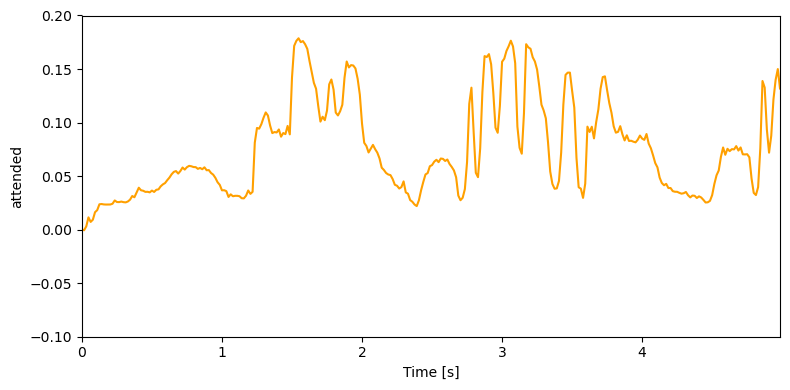

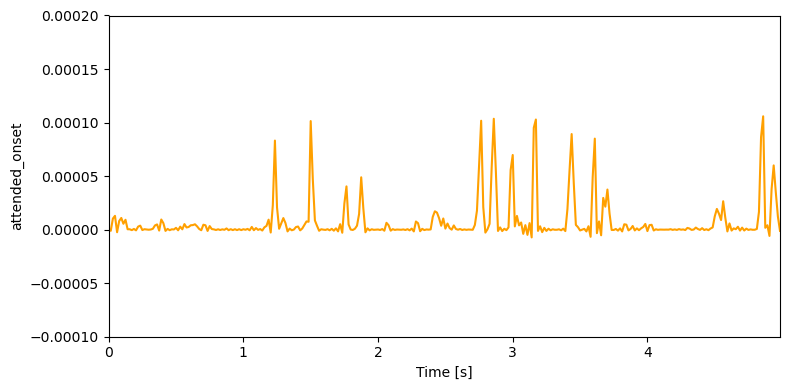

In [ ]:
# Sanity check: plot envelope and onset envelope for one trial
eelbrain.plot.UTS(attended_envelope[:5])
eelbrain.plot.UTS(att_onset[:5])